In [1]:
# ── Cell 1: Config Setup ─────────────────────────────────────
import os

BASE_DATASET_PATH = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'
WORKING_DIR       = '/kaggle/working'
CHECKPOINT_DIR    = os.path.join(WORKING_DIR, 'checkpoints')
LOG_DIR           = os.path.join(WORKING_DIR, 'logs')
EXPORT_DIR        = os.path.join(WORKING_DIR, 'exports')
IMAGE_SIZE        = (300, 300)
BATCH_SIZE        = 32
NUM_CLASSES       = 38
RANDOM_SEED       = 42

for directory in [CHECKPOINT_DIR, LOG_DIR, EXPORT_DIR]:
    os.makedirs(directory, exist_ok=True)

CLASS_NAMES = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___Cedar_apple_rust',
    'Apple___healthy',
    'Blueberry___healthy',
    'Cherry_(including_sour)___Powdery_mildew',
    'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___healthy',
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot',
    'Peach___healthy',
    'Pepper,_bell___Bacterial_spot',
    'Pepper,_bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch',
    'Strawberry___healthy',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy',
]

print(f"✓ Config loaded. Dataset path: {BASE_DATASET_PATH}")

✓ Config loaded. Dataset path: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color


In [2]:
# ── Cell 2: Imports ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("✓ All libraries imported")

✓ All libraries imported


In [3]:
# ── Cell 3: Class Distribution Analysis ──────────────────────
class_counts = {}

for class_name in CLASS_NAMES:
    class_path = os.path.join(BASE_DATASET_PATH, class_name)
    if os.path.exists(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        class_counts[class_name] = count
    else:
        class_counts[class_name] = 0
        print(f"⚠ Missing folder: {class_name}")

# Summary statistics
counts = list(class_counts.values())
total  = sum(counts)

print(f"\n{'='*50}")
print(f"DATASET SUMMARY")
print(f"{'='*50}")
print(f"Total images     : {total:,}")
print(f"Total classes    : {len(class_counts)}")
print(f"Max class size   : {max(counts):,}  ({CLASS_NAMES[counts.index(max(counts))]})")
print(f"Min class size   : {min(counts):,}  ({CLASS_NAMES[counts.index(min(counts))]})")
print(f"Mean class size  : {np.mean(counts):.0f}")
print(f"Imbalance ratio  : {max(counts)/min(counts):.1f}x")
print(f"{'='*50}")


DATASET SUMMARY
Total images     : 54,305
Total classes    : 38
Max class size   : 5,507  (Orange___Haunglongbing_(Citrus_greening))
Min class size   : 152  (Potato___healthy)
Mean class size  : 1429
Imbalance ratio  : 36.2x


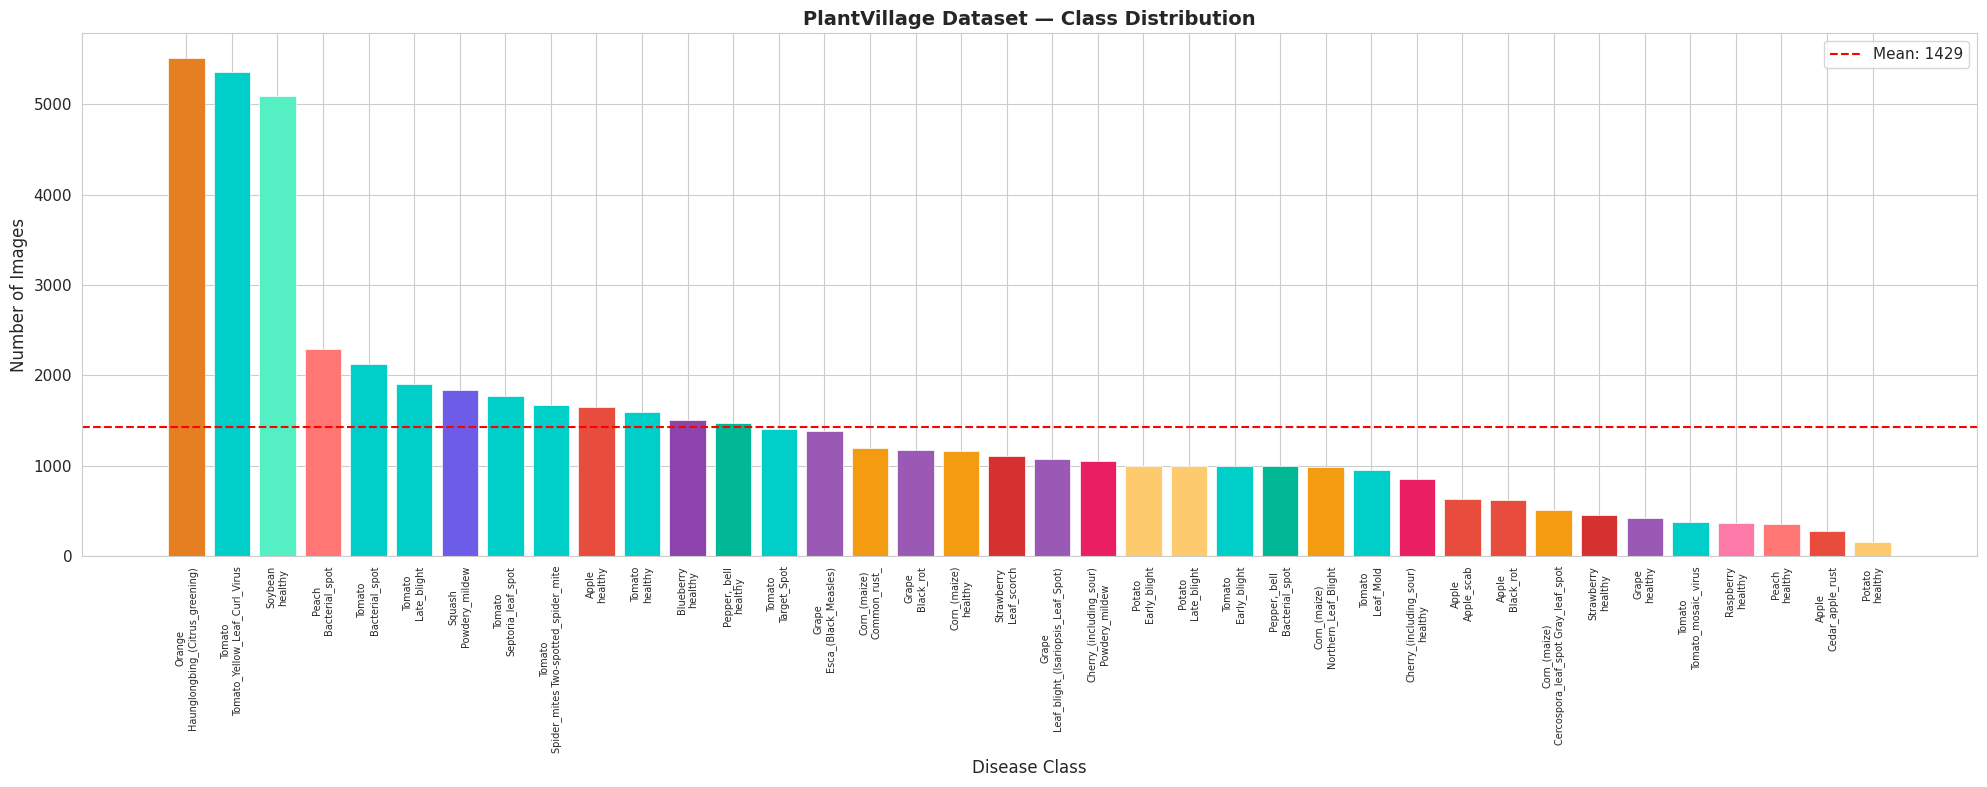

✓ Plot saved to logs/


In [4]:
# ── Cell 4: Class Distribution Plot ──────────────────────────
# Sort by count descending for easier reading
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
labels  = [c[0].replace('___', '\n') for c in sorted_classes]
values  = [c[1] for c in sorted_classes]

# Color bars by crop type for visual grouping
crop_colors = {
    'Apple': '#e74c3c', 'Blueberry': '#8e44ad', 'Cherry': '#e91e63',
    'Corn':  '#f39c12', 'Grape':     '#9b59b6', 'Orange': '#e67e22',
    'Peach': '#ff7675', 'Pepper':    '#00b894', 'Potato': '#fdcb6e',
    'Raspberry': '#fd79a8', 'Soybean': '#55efc4', 'Squash': '#6c5ce7',
    'Strawberry': '#d63031', 'Tomato': '#00cec9'
}

bar_colors = []
for cls, _ in sorted_classes:
    crop = cls.split('___')[0].split('_(')[0].split(',')[0]
    bar_colors.append(crop_colors.get(crop, '#95a5a6'))

fig, ax = plt.subplots(figsize=(20, 8))
bars = ax.bar(range(len(labels)), values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_xlabel('Disease Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('PlantVillage Dataset — Class Distribution', fontsize=14, fontweight='bold')
ax.axhline(y=np.mean(values), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(values):.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to logs/")

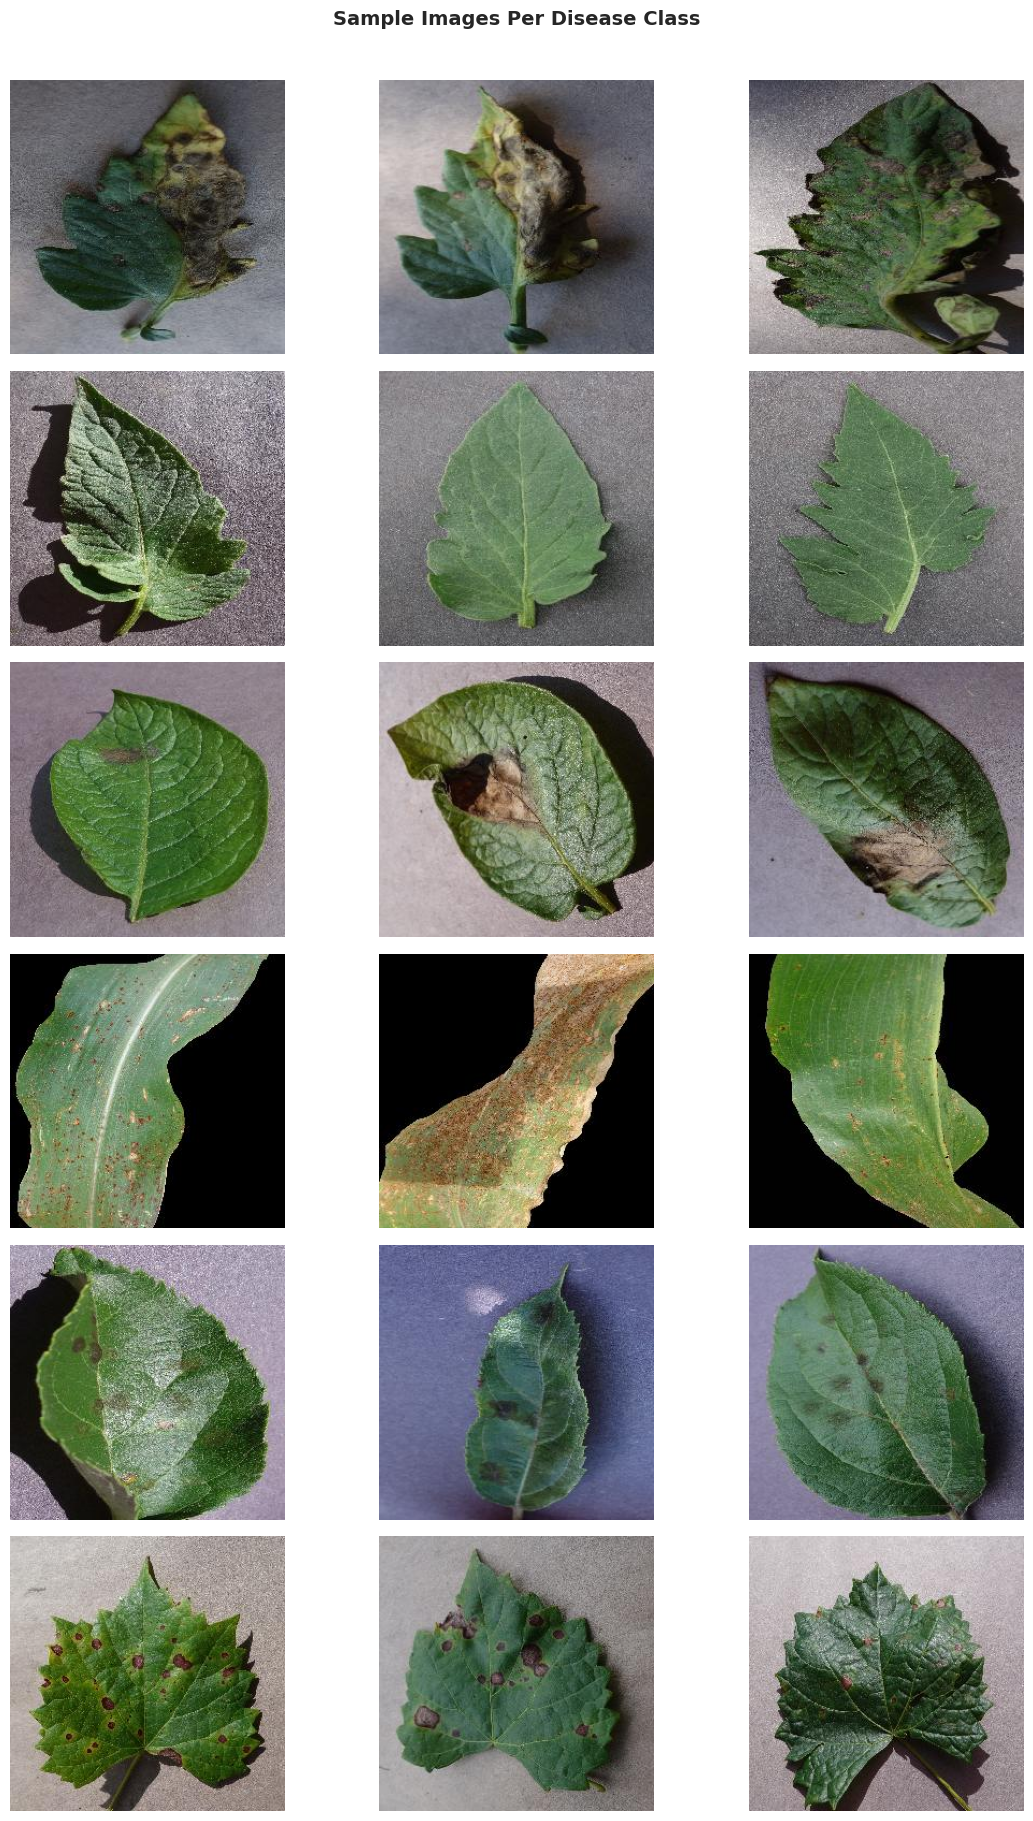

✓ Sample images saved to logs/


In [5]:
# ── Cell 5: Sample Image Visualization ───────────────────────
# Show 3 sample images from 6 different classes
sample_classes = [
    'Tomato___Early_blight',
    'Tomato___healthy',
    'Potato___Late_blight',
    'Corn_(maize)___Common_rust_',
    'Apple___Apple_scab',
    'Grape___Black_rot'
]

fig, axes = plt.subplots(len(sample_classes), 3, figsize=(12, 18))
fig.suptitle('Sample Images Per Disease Class', fontsize=14, fontweight='bold', y=1.01)

for row, class_name in enumerate(sample_classes):
    class_path = os.path.join(BASE_DATASET_PATH, class_name)
    images     = os.listdir(class_path)[:3]

    for col, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img      = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            # Clean label for display
            label = class_name.replace('___', '\n').replace('_', ' ')
            axes[row, col].set_ylabel(label, fontsize=9, rotation=0,
                                       labelpad=80, va='center')

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sample images saved to logs/")

In [6]:
# ── Cell 6: Image Dimension Analysis ─────────────────────────
# Sample 10 images from each class to check dimensions
print("Checking image dimensions across dataset...")
print("(Sampling 10 images per class for speed)\n")

widths, heights, aspect_ratios = [], [], []
dimension_issues = []

for class_name in CLASS_NAMES:
    class_path = os.path.join(BASE_DATASET_PATH, class_name)
    images     = os.listdir(class_path)[:10]

    for img_name in images:
        try:
            img = Image.open(os.path.join(class_path, img_name))
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)

            # Flag non-square images
            if abs(w - h) > 50:
                dimension_issues.append(f"{class_name}/{img_name}: {w}x{h}")
        except Exception as e:
            print(f"Could not open {img_name}: {e}")

print(f"{'='*50}")
print(f"IMAGE DIMENSION SUMMARY")
print(f"{'='*50}")
print(f"Width  — min: {min(widths)}px  max: {max(widths)}px  mean: {np.mean(widths):.0f}px")
print(f"Height — min: {min(heights)}px  max: {max(heights)}px  mean: {np.mean(heights):.0f}px")
print(f"Aspect ratio — min: {min(aspect_ratios):.2f}  max: {max(aspect_ratios):.2f}")
print(f"Non-square images found: {len(dimension_issues)}")
print(f"{'='*50}")
print(f"\n→ All images will be resized to {IMAGE_SIZE} during preprocessing.")
print(f"  Aspect ratio distortion is acceptable for disease classification.")

Checking image dimensions across dataset...
(Sampling 10 images per class for speed)

IMAGE DIMENSION SUMMARY
Width  — min: 256px  max: 256px  mean: 256px
Height — min: 256px  max: 256px  mean: 256px
Aspect ratio — min: 1.00  max: 1.00
Non-square images found: 0

→ All images will be resized to (300, 300) during preprocessing.
  Aspect ratio distortion is acceptable for disease classification.


Analyzing pixel value distributions...
(Sampling subset for speed)



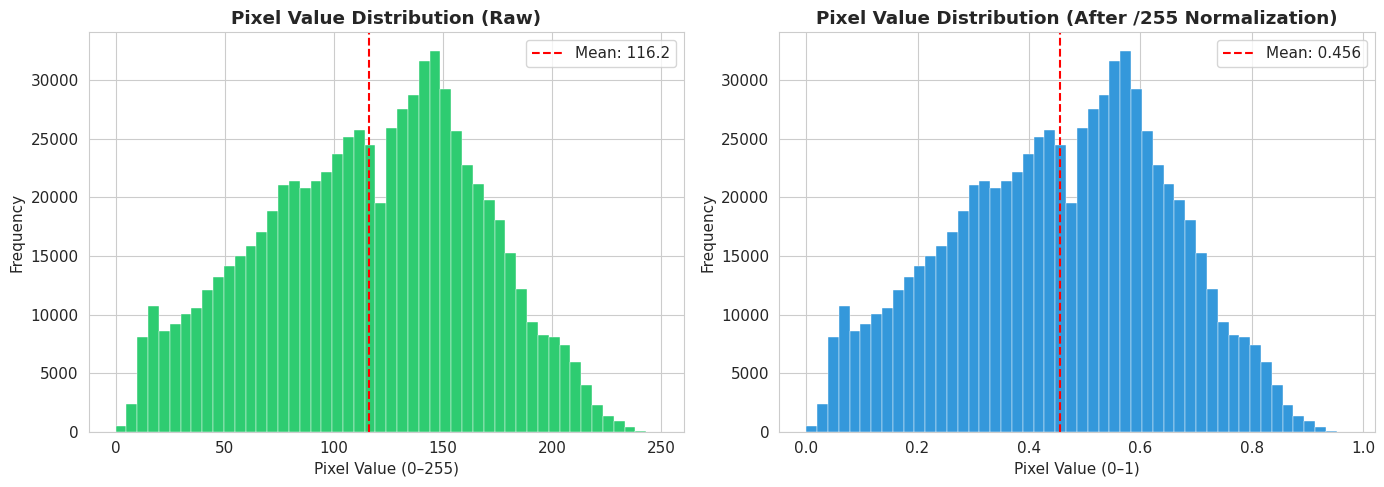


→ Raw pixel mean: 116.2 (expected ~127 for balanced dataset)
→ After normalization: values in [0, 1] range
→ EfficientNetB3 preprocessing will handle channel-wise normalization internally


In [7]:
# ── Cell 7: Pixel Value Distribution ─────────────────────────
# Sample 5 images from 5 classes for speed
print("Analyzing pixel value distributions...")
print("(Sampling subset for speed)\n")

sample_pixels = []
sample_classes_px = CLASS_NAMES[:5]

for class_name in sample_classes_px:
    class_path = os.path.join(BASE_DATASET_PATH, class_name)
    images     = os.listdir(class_path)[:5]

    for img_name in images:
        img    = Image.open(os.path.join(class_path, img_name)).resize((100, 100))
        pixels = np.array(img).flatten()
        sample_pixels.extend(pixels.tolist())

sample_pixels = np.array(sample_pixels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of pixel values
axes[0].hist(sample_pixels, bins=50, color='#2ecc71', edgecolor='white', linewidth=0.3)
axes[0].set_title('Pixel Value Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Pixel Value (0–255)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=sample_pixels.mean(), color='red', linestyle='--',
                label=f'Mean: {sample_pixels.mean():.1f}')
axes[0].legend()

# After normalization preview
normalized = sample_pixels / 255.0
axes[1].hist(normalized, bins=50, color='#3498db', edgecolor='white', linewidth=0.3)
axes[1].set_title('Pixel Value Distribution (After /255 Normalization)', fontweight='bold')
axes[1].set_xlabel('Pixel Value (0–1)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=normalized.mean(), color='red', linestyle='--',
                label=f'Mean: {normalized.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'pixel_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n→ Raw pixel mean: {sample_pixels.mean():.1f} (expected ~127 for balanced dataset)")
print(f"→ After normalization: values in [0, 1] range")
print(f"→ EfficientNetB3 preprocessing will handle channel-wise normalization internally")

In [8]:
# ── Cell 8: Exploration Summary ──────────────────────────────
print("="*55)
print("DATA EXPLORATION COMPLETE — KEY FINDINGS")
print("="*55)

sorted_counts = sorted(class_counts.items(), key=lambda x: x[1])

print(f"\n1. DATASET SIZE")
print(f"   {total:,} total images across {NUM_CLASSES} disease classes")

print(f"\n2. CLASS IMBALANCE")
print(f"   Smallest class : {sorted_counts[0][0]}")
print(f"                    {sorted_counts[0][1]:,} images")
print(f"   Largest class  : {sorted_counts[-1][0]}")
print(f"                    {sorted_counts[-1][1]:,} images")
print(f"   Imbalance ratio: {sorted_counts[-1][1]/sorted_counts[0][1]:.1f}x")
print(f"   → Will handle with class_weight in model.fit()")

print(f"\n3. IMAGE DIMENSIONS")
print(f"   Images vary in size — will resize all to {IMAGE_SIZE}")
print(f"   → Resizing handled in preprocessing pipeline")

print(f"\n4. PIXEL VALUES")
print(f"   Raw range: 0–255")
print(f"   → Will normalize to 0–1 by dividing by 255")
print(f"   → EfficientNetB3 applies its own internal normalization on top")

print(f"\n5. NEXT STEP")
print(f"   → Proceed to 02_preprocessing.ipynb")
print(f"   → Build tf.data pipeline with augmentation")
print("="*55)

DATA EXPLORATION COMPLETE — KEY FINDINGS

1. DATASET SIZE
   54,305 total images across 38 disease classes

2. CLASS IMBALANCE
   Smallest class : Potato___healthy
                    152 images
   Largest class  : Orange___Haunglongbing_(Citrus_greening)
                    5,507 images
   Imbalance ratio: 36.2x
   → Will handle with class_weight in model.fit()

3. IMAGE DIMENSIONS
   Images vary in size — will resize all to (300, 300)
   → Resizing handled in preprocessing pipeline

4. PIXEL VALUES
   Raw range: 0–255
   → Will normalize to 0–1 by dividing by 255
   → EfficientNetB3 applies its own internal normalization on top

5. NEXT STEP
   → Proceed to 02_preprocessing.ipynb
   → Build tf.data pipeline with augmentation
